In [1]:
from starccato_flow.training.trainer_flow_matching_multi import FlowMatchingTrainerMulti

MPS device found


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
trainer = FlowMatchingTrainerMulti(num_epochs=1, toy=False, parameters=["Ye_c_b", "ra", "dec", "d", "psi"])
trainer.load_model_instance(model_path="outdir/flow_ye_sky_weights.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['Ye_c_b', 'ra', 'dec', 'd', 'psi']
Intrinsic params: ['Ye_c_b']
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3, 4]
Final flow parameter dimension: 5

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (1 parameters)
Ye_c_b              : [    0.246499,     0.282820]


=== Data Split ===
Total signals: 1684
Training signals: 1516
Validation signals: 168
First 5 training indices: [ 360  336   81  684 1374]
First 5 validation indices: [722 519 222  32 111]

sTheta Dataset - Parameter Bounds (1 parameters)
Ye_c_b              : [    0.246499,     0.282820]


sTheta Dataset - Parameter Bounds (1 parameters)
Ye_c_b              : [    0.246499,     0.282820]


Verifying data alignment:
Number of signals: 1516
Number of parameter sets: 1516
Parameter name


hThetaMulti Dataset - Parameter Bounds (5 parameters)
INTRINSIC PARAMETERS:
  Ye_c_b              : [    0.246499,     0.282820]

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [   -3.141593,     3.141593]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    20.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 5
Parameters include theta + sky: [ra, dec, d, polar_angle]


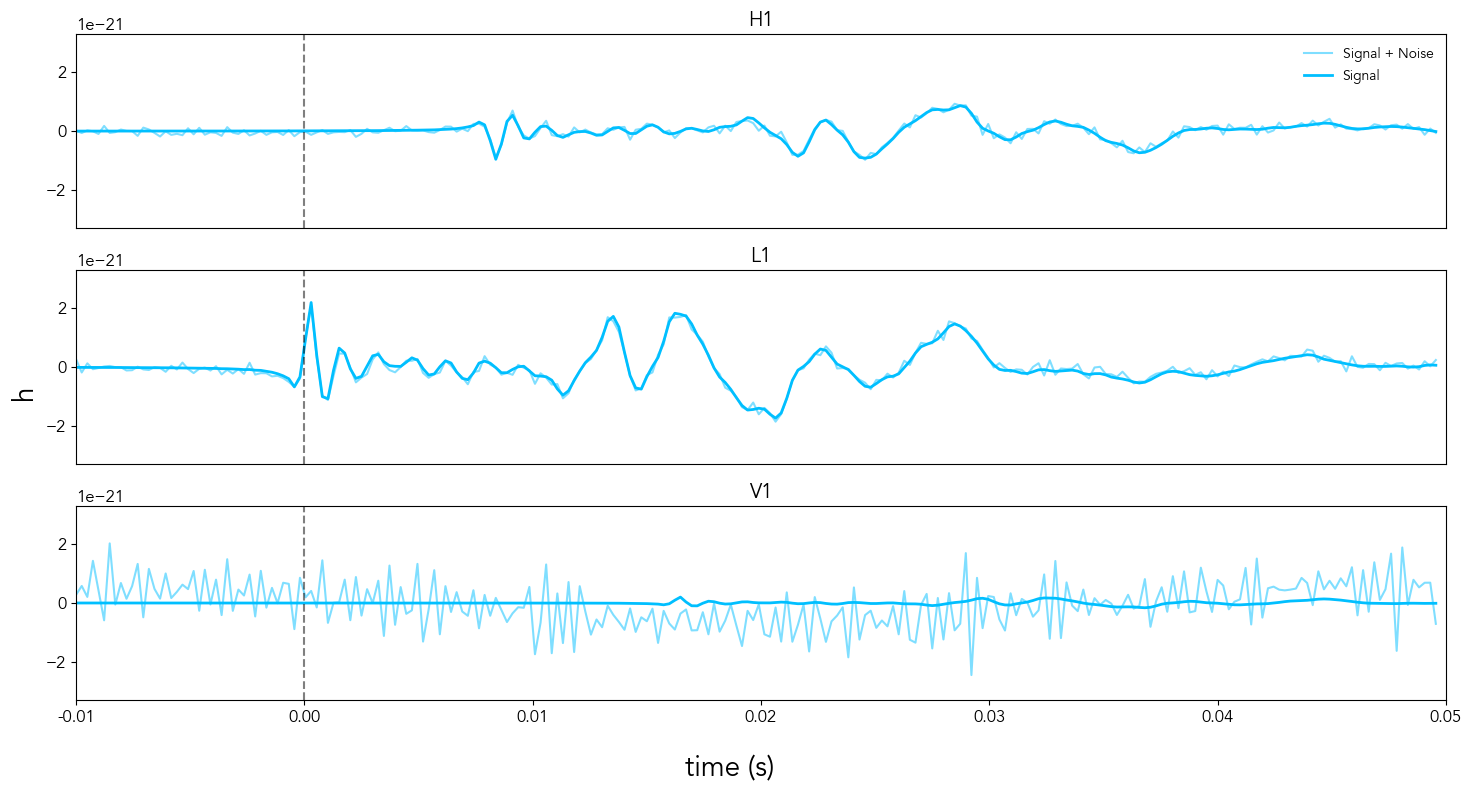

Posterior sampling and denormalisation took 0.16s

Plot axis ranges (extracted parameter space):
  Ye_c_b              : (0.2454093098640442, 0.2839096188545227)
  ra                  : (-3.3300883769989014, 3.3300883769989014)
  dec                 : (-1.6650441884994507, 1.6650441884994507)
  d                   : (-0.5999999642372131, 20.600000381469727)
  psi                 : (-0.09424778074026108, 3.2358405590057373)
  Override d range to: (0.1, 20.0)


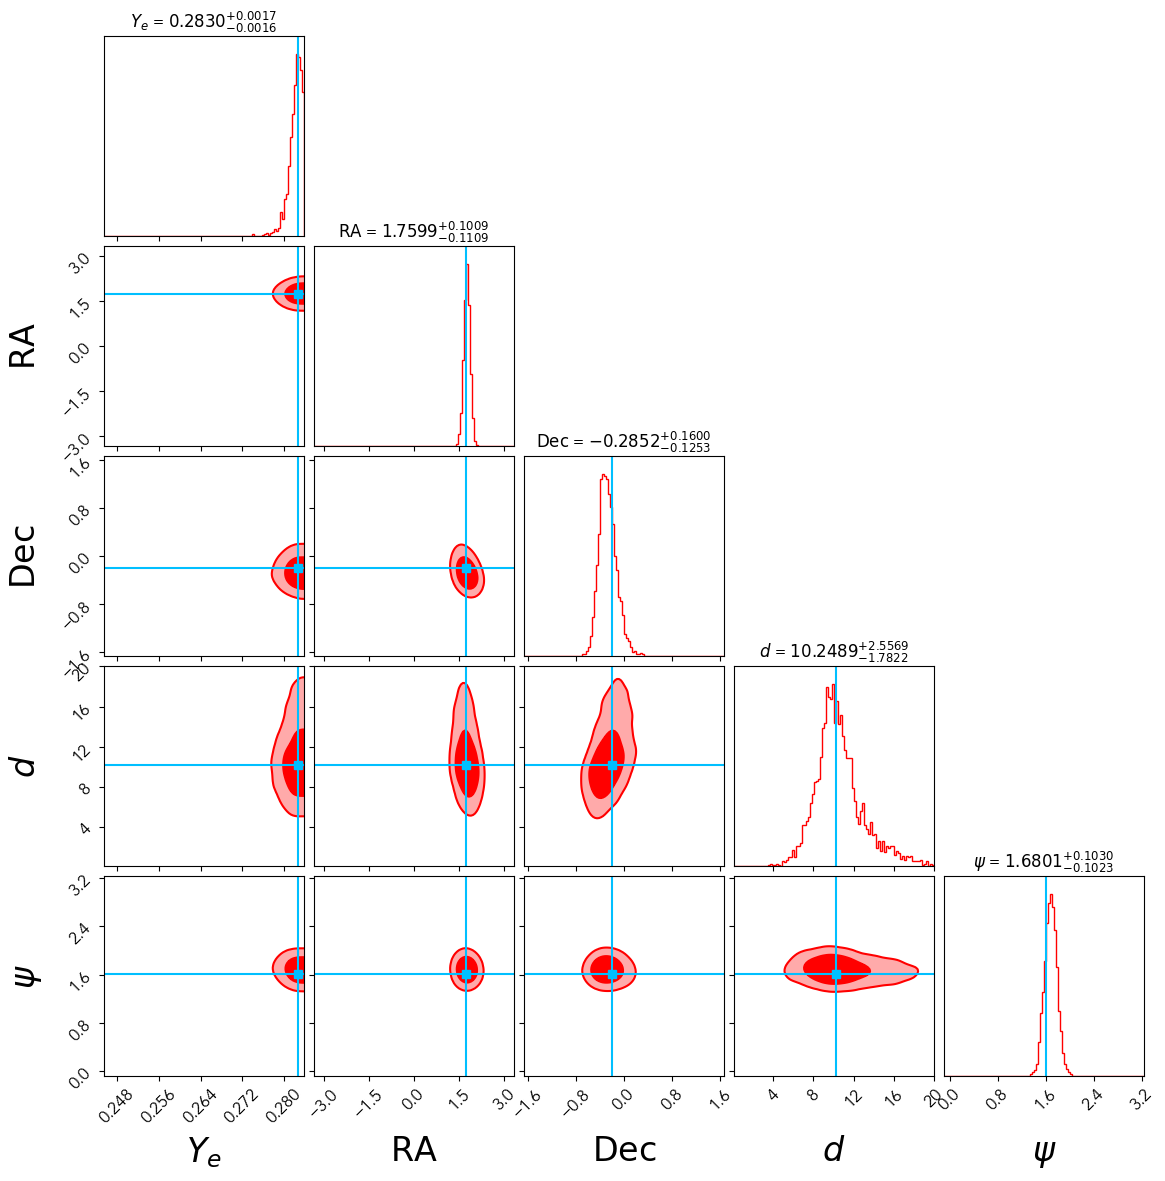


Galactic Center Direction:
  RA:  2.730630 rad = 156.45°
  Dec: -1.048155 rad = -60.05°



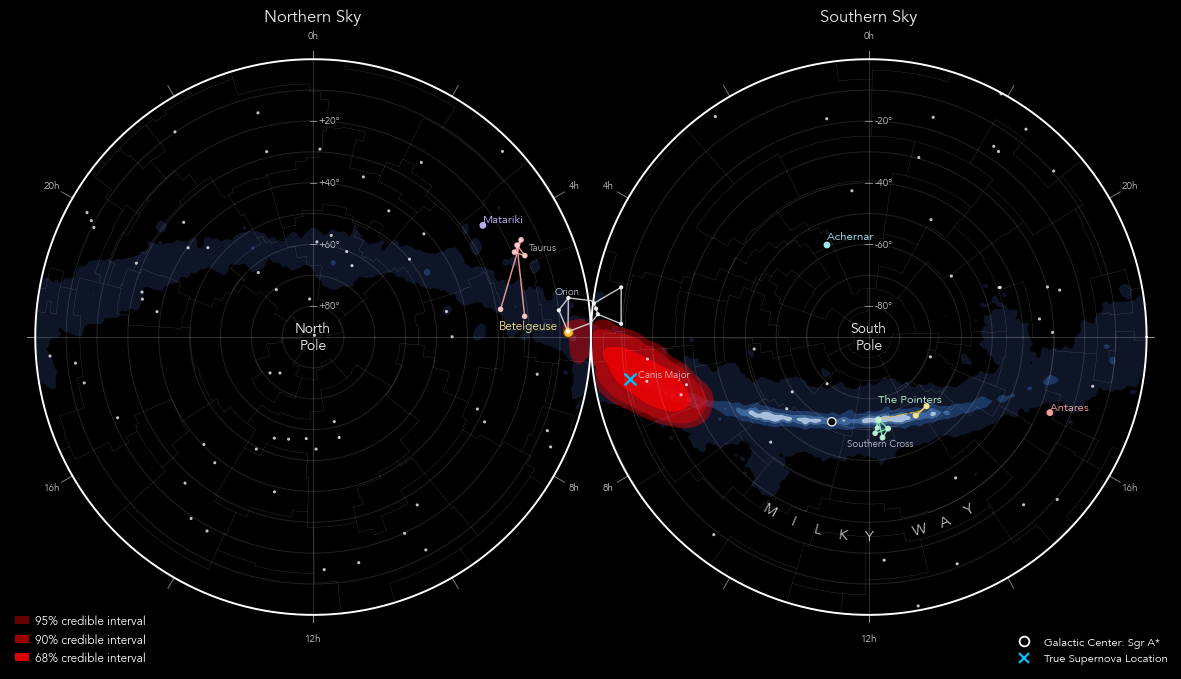

/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/parameters.py:792: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


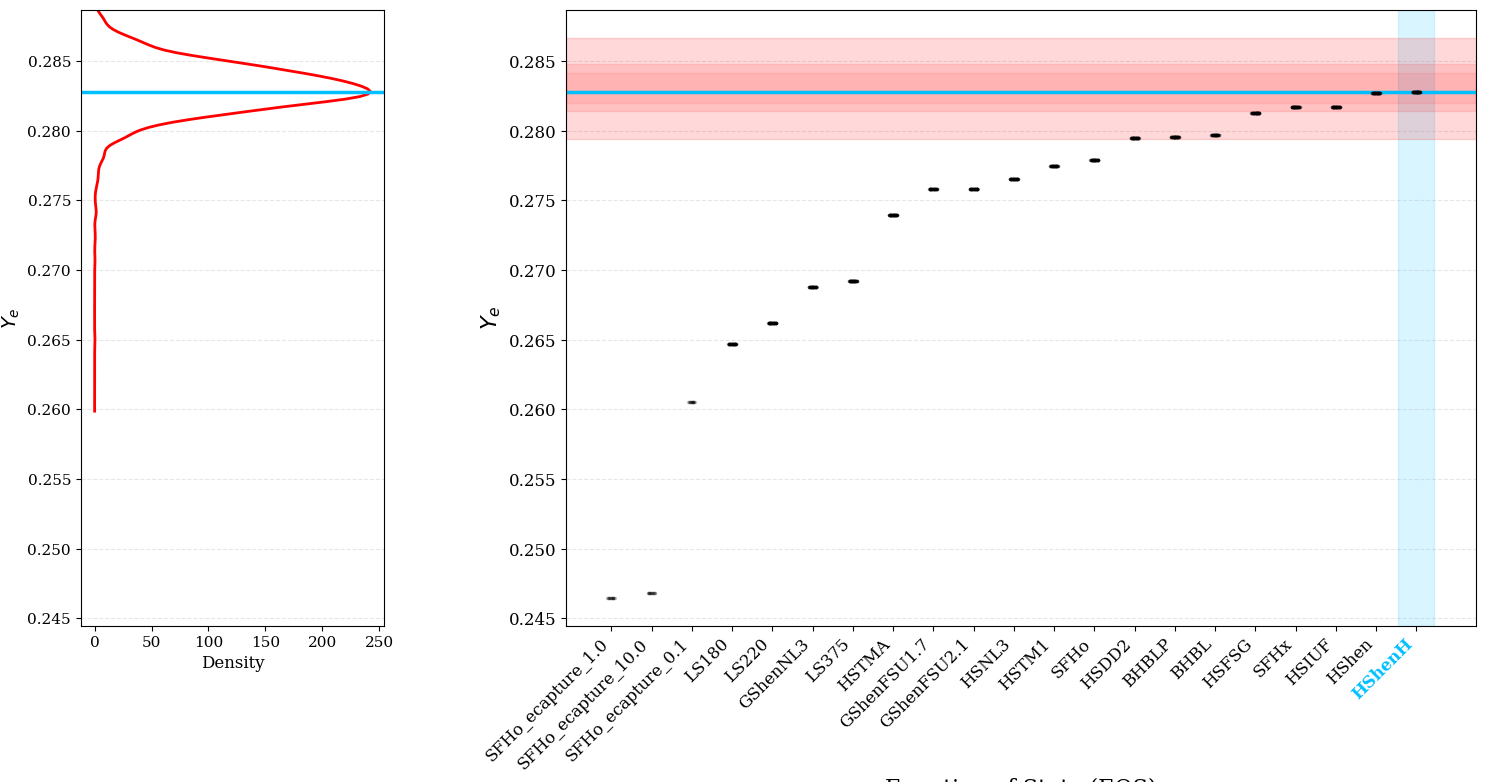

In [8]:
trainer.run_parameter_estimation(signal_idx=40, d=10.0, ra=None, dec=None, export_on=True)

In [4]:
# trainer.plot_pp_coverage_validation(background="white", font_family="Serif", font_name="Times New Roman")

In [5]:
# import os
# import glob
# from pathlib import Path
# from PIL import Image
# import numpy as np

# # Generate parameter estimations for d values from 1.0 to 20.0
# d_values = [float(d) for d in range(1, 21)]  # 1.0 to 20.0
# signal_idx = 5
# random_psi = False  # Set to False for fixed psi=0, True for random

# print(f"Generating parameter estimations for d values: {d_values}")
# print(f"Using {'random' if random_psi else 'fixed (psi=0)'} polarization angle")

# ra = np.deg2rad(100)
# dec = np.deg2rad(-30)

# # Set up directories
# epoch_data_dir = os.path.join(trainer.outdir, "flow_matching", "epoch_data")
# plots_dir = Path(trainer.outdir)

# # Clean up old frame files before generating new ones
# print(f"Cleaning up old frame files...")
# for old_file in glob.glob(os.path.join(epoch_data_dir, f"signal_{signal_idx:04d}_ra_100.0_dec_-30.0_d_*")):
#     try:
#         os.remove(old_file)
#         print(f"  Removed: {os.path.basename(old_file)}")
#     except Exception as e:
#         print(f"  Failed to remove {old_file}: {e}")

# for d in d_values:
#     print(f"Processing d={d:.1f}...")
#     # Pass random_psi parameter to control polarization behavior
#     trainer.run_parameter_estimation(signal_idx=signal_idx, d=d, ra=ra, dec=dec, export_on=False, random_psi=random_psi)

# def create_gif_from_pattern(pattern, output_gif_path, duration_ms=500):
#     """Create animated GIF from PNG images matching a pattern."""
#     image_files = sorted(glob.glob(pattern))
    
#     if not image_files:
#         print(f"No images found for pattern: {pattern}")
#         return
    
#     print(f"Creating GIF from {len(image_files)} images: {output_gif_path}")
    
#     images = [Image.open(fp) for fp in image_files]
#     images[0].save(
#         output_gif_path,
#         save_all=True,
#         append_images=images[1:],
#         duration=duration_ms,
#         loop=0,
#         optimize=False,
#         disposal=2,
#     )
#     for img in images:
#         img.close()
#     print(f"✓ Saved GIF: {output_gif_path}")

# # Create signal GIF (with ra/dec in filename)
# signal_pattern = os.path.join(epoch_data_dir, f"signal_{signal_idx:04d}_ra_100.0_dec_-30.0_d_*_signal.png")
# signal_gif = plots_dir / f"signal_{signal_idx:04d}_d_sweep_signal.gif"
# create_gif_from_pattern(signal_pattern, str(signal_gif), duration_ms=280)

# # Create corner plot GIF (with ra/dec in filename)
# corner_pattern = os.path.join(epoch_data_dir, f"signal_{signal_idx:04d}_ra_100.0_dec_-30.0_d_*_corner.png")
# corner_gif = plots_dir / f"signal_{signal_idx:04d}_d_sweep_corner.gif"
# create_gif_from_pattern(corner_pattern, str(corner_gif), duration_ms=280)

# # Create sky localization GIF (with ra/dec in filename)
# sky_pattern = os.path.join(epoch_data_dir, f"signal_{signal_idx:04d}_ra_100.0_dec_-30.0_d_*_sky.png")
# sky_gif = plots_dir / f"signal_{signal_idx:04d}_d_sweep_sky.gif"
# create_gif_from_pattern(sky_pattern, str(sky_gif), duration_ms=280)

# print("\n✓ GIF creation complete!")
# print(f"Output GIFs saved to: {plots_dir}")